# Part1.2: Null Values

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
train=pd.read_csv("C:\\Users\\Hzaab\\Desktop\\MLSD project\\data\\raw\\train.csv")
train=train.drop(columns=["Unnamed: 0"])


train % missing:



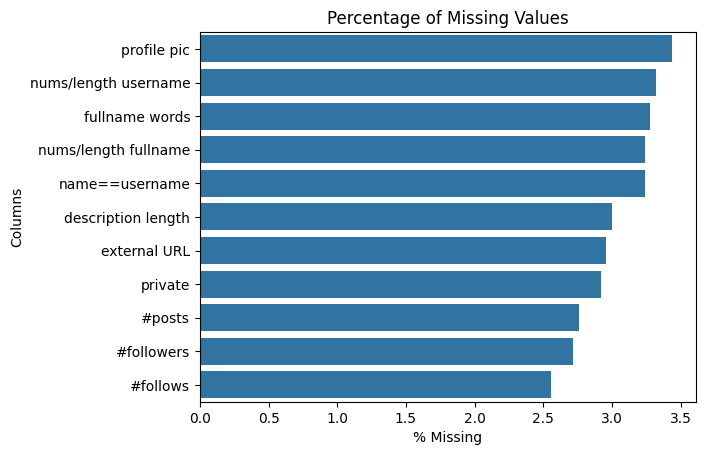

In [13]:
print("train % missing:\n")

nulls = train.isnull()
avgNulls = nulls.mean() * 100
nulls = nulls[nulls > 0]
avgNulls = avgNulls[avgNulls > 0]
columnsWithNulls = avgNulls.index
avgNulls.sort_values(inplace=True, ascending=False)

plt.figure()
sns.barplot(y=columnsWithNulls, x=avgNulls.values)

plt.title("Percentage of Missing Values")
plt.ylabel("Columns")
plt.xlabel("% Missing")

plt.show()

## Analysis of the Null Values matrix

There doesn't seem to be ay specific feature or data input that is mostly missing, the missingsness looks random

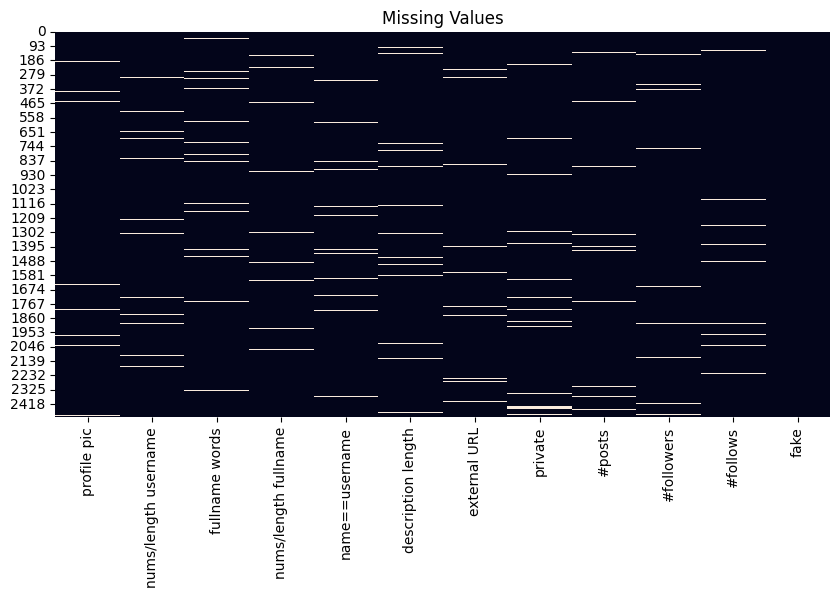

In [5]:
plt.figure(figsize=(10, 5))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

taking a closer look at the rows, there isnt any data point with more than 3 missing, which we decided is not bad (????? idk how to phrase)

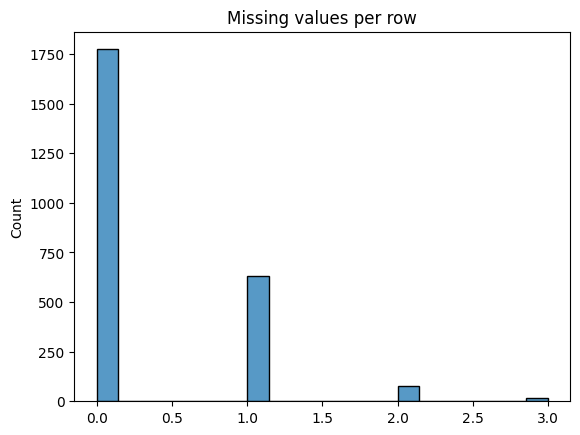

In [9]:

ax = sns.histplot(nulls.sum(axis=1))

plt.title("Missing values per row")

plt.show()

## Null values and Target value

looking at the % values missing from each output class, they seem to be almost equal. Note: we used % due to the class imbalance

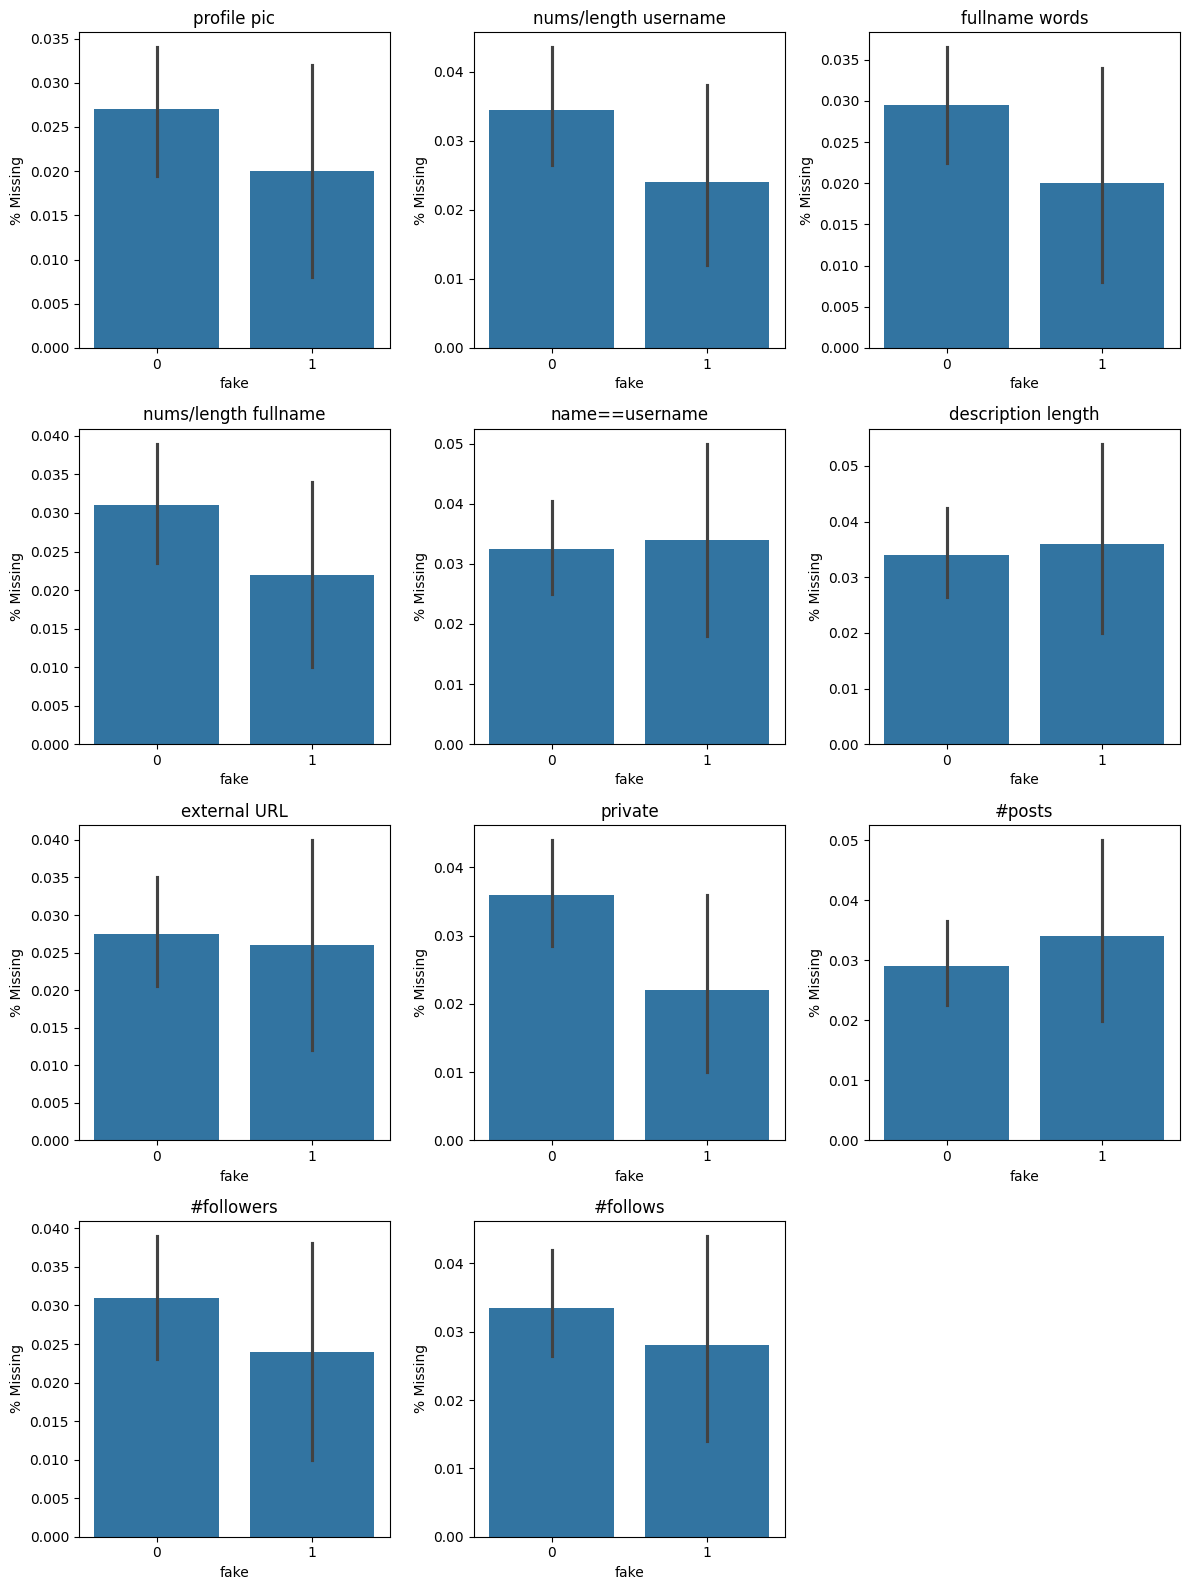

In [15]:
nullAvg = train.isnull().mean()
nullAvg = nullAvg[nullAvg > 0]
n = len(nullAvg)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

for i, col in enumerate(columnsWithNulls): 
    ax = axes[i]
    
    temp = train.copy()
    temp["missing"] = temp[col].isnull()

    sns.barplot(data=temp, x="fake", y="missing", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("% Missing")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

further checking the correlation between the output class and the features, all correlations are ~0

In [8]:
missings = train.isnull().astype(int)
missings["fake"] = train["fake"]

corr = missings.corr()["fake"].drop("fake").sort_values(ascending=False)
print(corr)

#posts                  0.011724
description length      0.004389
name==username          0.003369
external URL           -0.003689
#follows               -0.012425
#followers             -0.016521
profile pic            -0.017728
nums/length fullname   -0.021382
fullname words         -0.023196
nums/length username   -0.023721
private                -0.031257
Name: fake, dtype: float64


## Correlation across features
we also graphed the correlation matrix of the missing values across features, to check if one feature is causing the other to be missing, however the correlations were all insignificant

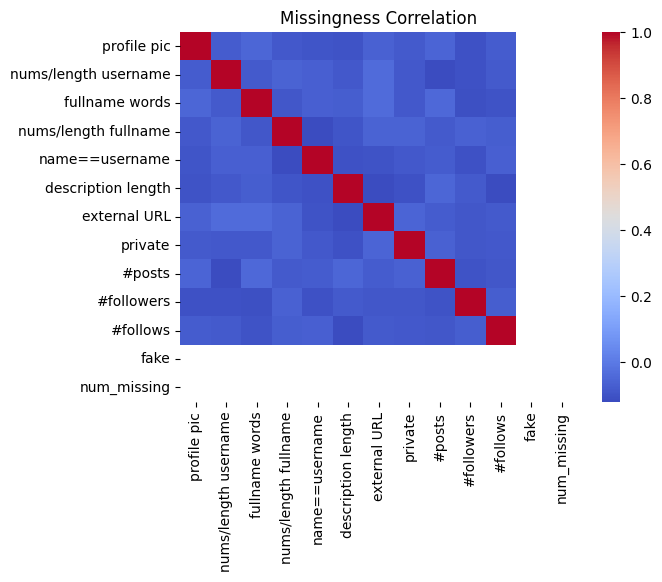

In [62]:
sns.heatmap(train.isnull().corr(), cmap="coolwarm")
plt.title("Missingness Correlation")
plt.show()

## We conclude that the values are Missing Completely at Random (MCAR)
Hence we will use median imputation for numerical features and the mode for categorical features